# El CO₂ enfría la estratosfera (y eso amplifica su forzamiento)

> El CO₂ no solo calienta el suelo: **enfría** la estratosfera. Y ese enfriamiento amplifica su propio efecto invernadero.

**Paper:** Cohen et al. (2026) — *Stratospheric cooling and amplification of radiative forcing with rising carbon dioxide* — *Nature Geoscience*  \
**DOI:** [10.1038/s41561-026-01965-8](https://doi.org/10.1038/s41561-026-01965-8)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-13-co2-enfria-estratosfera/notebook.ipynb)

> 🎬 Video corto: [Pendiente]

## Lo que hicieron

El equipo de Cohen usó un modelo radiativo idealizado (Konrad — una columna 1D que resuelve transferencia radiativa con química atmosférica fija) y lo corrió a **seis** concentraciones de CO₂: desde 0,25 × pre-industrial (70 ppm) hasta 8 × pre-industrial (2240 ppm). Para cada escenario midieron el perfil vertical de temperatura desde la superficie hasta la mesosfera, y calcularon el forzamiento radiativo en el tope de la atmósfera.

En paralelo cruzaron esos resultados teóricos con tendencias decadales reales: 36 modelos CMIP6 y 3 reanálisis (ERA5, JRA-55, MERRA-2).

La pregunta de fondo: ¿por qué la huella vertical del CO₂ es así de característica — calentar abajo, enfriar arriba — y por qué la tropopausa no se mueve?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CO2_PI = 280                           # ppm — pre-industrial baseline
ESCENARIO_HERO = '2xPI'                # qué doubling resaltar
NIVEL_REFERENCIA_HPA = 100             # tropopausa
FUENTE = 'Fuente: Cohen et al. (2026), Nature Geoscience | Datos: Zenodo 16929030'
COLOR_PI = '#2563EB'                   # azul CaM — baseline
COLOR_2XPI = '#DC2626'                 # rojo — perturbación
COLOR_REANALYSIS = '#D97706'           # amber — observación
COLOR_GRIS = '#BBBBBB'                 # CMIP6 spread

# ── Setup ────────────────────────────────────────────────────
import os, sys, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Estilo CaM (local → fallback raw GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ── Carga ────────────────────────────────────────────────────
konrad   = pd.read_csv('datos/konrad_perfil_temperatura.csv')
cmip6    = pd.read_csv('datos/cmip6_tendencia_vertical.csv')
heating  = pd.read_csv('datos/tasas_calentamiento_por_especie.csv')
erf_dbl  = pd.read_csv('datos/forzamiento_vs_doubling.csv')
erf_sst  = pd.read_csv('datos/forzamiento_vs_sst.csv')

print(f"Konrad: {konrad['escenario'].nunique()} escenarios × {konrad.groupby('escenario').size().iloc[0]} niveles verticales")
print(f"CMIP6:  {cmip6.groupby('familia')['modelo'].nunique().to_dict()} modelos")
print(f"ERF/IRF: {len(erf_dbl)} doublings + {len(erf_sst)} valores de SST")

Konrad: 6 escenarios × 128 niveles verticales
CMIP6:  {'CMIP6': 36, 'Reanalysis': 3} modelos
ERF/IRF: 4 doublings + 7 valores de SST


## Aquí está.

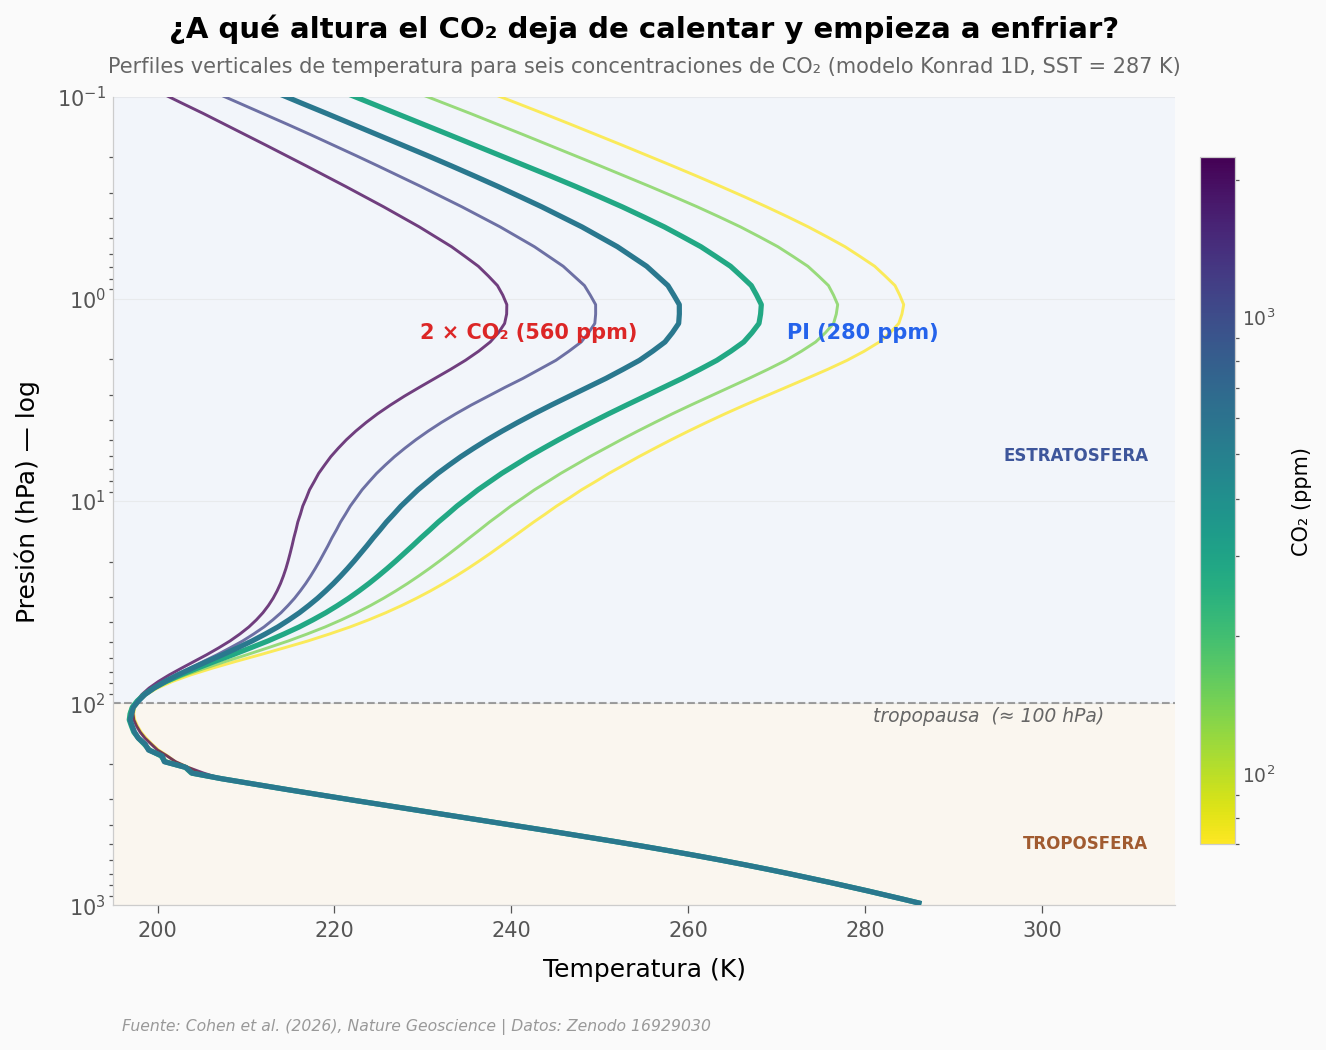

In [2]:
fig, ax = plt.subplots(figsize=(11, 7))

# Orden de escenarios y mapeo a CO2 en ppm
orden = ['0.25xPI', '0.5xPI', '1xPI', '2xPI', '4xPI', '8xPI']
ppm_map = {'0.25xPI': 70, '0.5xPI': 140, '1xPI': 280, '2xPI': 560, '4xPI': 1120, '8xPI': 2240}

# Colormap viridis_r para CO2 creciente
norm = mcolors.LogNorm(vmin=70, vmax=2240)
cmap = plt.cm.viridis_r

for esc in orden:
    sub = konrad[konrad['escenario'] == esc].sort_values('presion_hpa')
    color = cmap(norm(ppm_map[esc]))
    lw = 2.5 if esc in ('1xPI', '2xPI') else 1.4
    alpha = 1.0 if esc in ('1xPI', '2xPI') else 0.75
    ax.plot(sub['temperatura_k'], sub['presion_hpa'],
            color=color, linewidth=lw, alpha=alpha, zorder=5 if esc in ('1xPI','2xPI') else 3)

# Línea de tropopausa
ax.axhline(y=100, color='#666666', linestyle='--', linewidth=1.0, alpha=0.6, zorder=2)
ax.text(307, 105, 'tropopausa  (≈ 100 hPa)', fontsize=9, color='#666666',
        ha='right', va='top', style='italic')

# Anotaciones inline labels (PI y 2xPI)
sub_pi = konrad[konrad['escenario']=='1xPI'].sort_values('presion_hpa')
sub_2x = konrad[konrad['escenario']=='2xPI'].sort_values('presion_hpa')
# Punto a 3 hPa para etiquetar
def pick_t(df, p_target):
    idx = (df['presion_hpa'] - p_target).abs().idxmin()
    return df.loc[idx, 'temperatura_k'], df.loc[idx, 'presion_hpa']
t_pi, p_pi = pick_t(sub_pi, 1.5)
t_2x, p_2x = pick_t(sub_2x, 1.5)
ax.text(t_pi + 4, p_pi, 'PI (280 ppm)', color=COLOR_PI, fontsize=10,
        fontweight='bold', va='center')
ax.text(t_2x - 4, p_2x, '2 × CO₂ (560 ppm)', color=COLOR_2XPI, fontsize=10,
        fontweight='bold', va='center', ha='right')

# Sombrear bandas estratosfera vs troposfera
ax.axhspan(100, 1000, color='#FBBF24', alpha=0.05, zorder=1)
ax.axhspan(0.1, 100, color='#60A5FA', alpha=0.05, zorder=1)
ax.text(312, 500, 'TROPOSFERA', fontsize=8, color='#92400E',
        ha='right', va='center', fontweight='bold', alpha=0.85)
ax.text(312, 6, 'ESTRATOSFERA', fontsize=8, color='#1E3A8A',
        ha='right', va='center', fontweight='bold', alpha=0.85)

# Colorbar como leyenda de CO2
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('CO₂ (ppm)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_yscale('log')
ax.invert_yaxis()
ax.set_xlabel('Temperatura (K)')
ax.set_ylabel('Presión (hPa) — log')
ax.set_xlim(195, 315)
ax.set_ylim(1000, 0.1)
ax.set_title('¿A qué altura el CO₂ deja de calentar y empieza a enfriar?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Perfiles verticales de temperatura para seis concentraciones de CO₂ (modelo Konrad 1D, SST = 287 K)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.01, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/perfil_vertical_co2.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que llama la atención:

- **Abajo, en la troposfera, las curvas casi se tocan.** Más CO₂ calienta la superficie, pero la diferencia entre 70 ppm y 2240 ppm es pequeña en esta vista — porque la SST (temperatura superficial del mar) es fija en el modelo (287 K). El calentamiento aquí depende de la dinámica climática que Konrad no captura.
- **Arriba, las curvas se separan dramáticamente.** A 1 hPa (≈ 48 km), pasar de PI a 2 × CO₂ enfría la estratopausa **9,4 K** — y a 8 × CO₂, **29 K** menos que el escenario pre-industrial. El enfriamiento crece con la altura.
- **La tropopausa no se mueve.** A 100 hPa la temperatura oscila entre 197,61 y 197,89 K para todos los escenarios. La frontera entre troposfera y estratosfera está **clavada** por la física espectroscópica del CO₂.

Esa es la huella vertical: arriba enfría, abajo calienta, y el límite entre ambas zonas es invariante.

## ¿Y la atmósfera real?

Konrad es un modelo idealizado. La pregunta honesta: ¿la atmósfera real está mostrando esta huella? Veamos las tendencias decadales — cuántos grados por década está subiendo (o bajando) la temperatura a cada altura — en 36 modelos CMIP6 y 3 reanálisis observacionales.

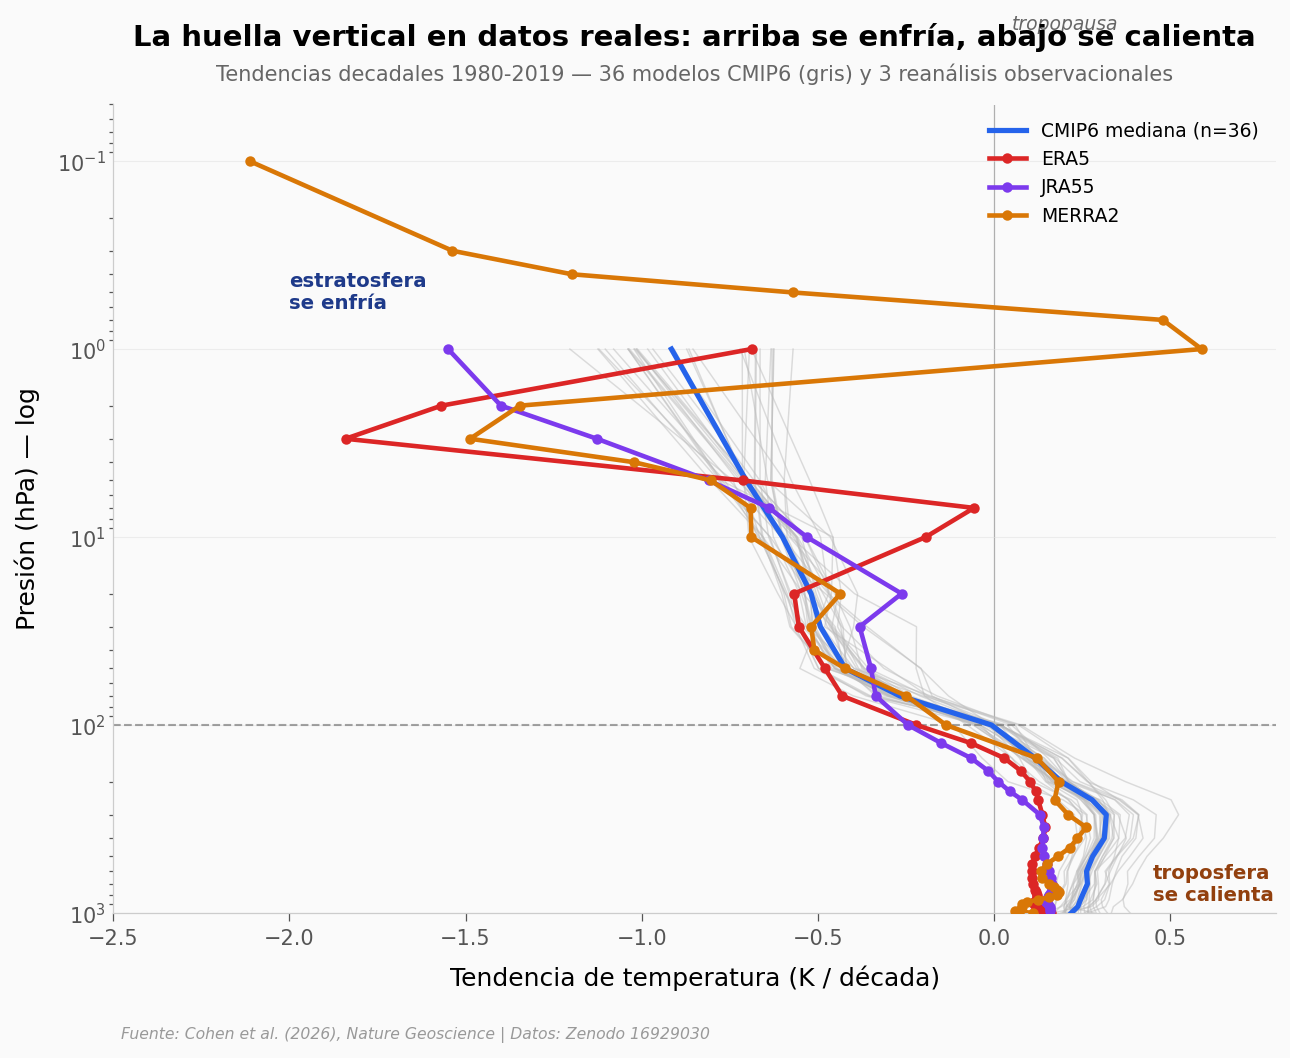

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))

# 36 CMIP6 individuales en gris claro
modelos_cmip6 = cmip6[cmip6['familia']=='CMIP6']['modelo'].unique()
for m in modelos_cmip6:
    sub = cmip6[(cmip6['familia']=='CMIP6') & (cmip6['modelo']==m)].sort_values('presion_hpa')
    ax.plot(sub['tendencia_k_decada'], sub['presion_hpa'],
            color=COLOR_GRIS, linewidth=0.7, alpha=0.5, zorder=2)

# Mediana CMIP6
mediana_cmip6 = (cmip6[cmip6['familia']=='CMIP6']
                 .groupby('presion_hpa')['tendencia_k_decada'].median()
                 .reset_index().sort_values('presion_hpa'))
ax.plot(mediana_cmip6['tendencia_k_decada'], mediana_cmip6['presion_hpa'],
        color=COLOR_PI, linewidth=2.5, label='CMIP6 mediana (n=36)', zorder=5)

# Reanálisis — cada uno como línea distinta
colores_rea = {'ERA5': '#DC2626', 'JRA55': '#7C3AED', 'MERRA2': '#D97706'}
for rea in ['ERA5', 'JRA55', 'MERRA2']:
    sub = cmip6[cmip6['modelo']==rea].sort_values('presion_hpa')
    if len(sub) > 0:
        ax.plot(sub['tendencia_k_decada'], sub['presion_hpa'],
                color=colores_rea[rea], linewidth=2.2, label=rea,
                marker='o', markersize=4, zorder=6)

# Línea cero
ax.axvline(x=0, color='#666666', linestyle='-', linewidth=0.6, alpha=0.5, zorder=1)
# Tropopausa
ax.axhline(y=100, color='#666666', linestyle='--', linewidth=1.0, alpha=0.6, zorder=2)
ax.text(0.05, 0.02, 'tropopausa', transform=ax.transData,
        fontsize=9, color='#666666', style='italic')

# Anotaciones de zonas
ax.text(-2.0, 0.5, 'estratosfera\nse enfría', fontsize=9.5, color='#1E3A8A',
        fontweight='bold', ha='left', va='center')
ax.text(0.45, 700, 'troposfera\nse calienta', fontsize=9.5, color='#92400E',
        fontweight='bold', ha='left', va='center')

ax.set_yscale('log')
ax.invert_yaxis()
ax.set_xlabel('Tendencia de temperatura (K / década)')
ax.set_ylabel('Presión (hPa) — log')
ax.set_xlim(-2.5, 0.8)
ax.set_ylim(1000, 0.05)
ax.set_title('La huella vertical en datos reales: arriba se enfría, abajo se calienta',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Tendencias decadales 1980-2019 — 36 modelos CMIP6 (gris) y 3 reanálisis observacionales',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.92)

fig.text(0.13, -0.01, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tendencias_decadales.png', dpi=200, bbox_inches='tight')
plt.show()

## Pero la huella vertical no es solo una marca. Amplifica.

Aquí entra el concepto clave del paper. El **forzamiento radiativo instantáneo** (IRF) es lo que mide el efecto invernadero "puro": cuánta energía atrapa el CO₂ extra antes de que la atmósfera responda. El **forzamiento efectivo** (ERF) incluye el ajuste de temperatura de la estratosfera — porque al enfriarse, la estratosfera **emite menos energía al espacio**, así que la atmósfera retiene aún más calor.

La pregunta: ¿cuánto amplifica el enfriamiento estratosférico al forzamiento original?

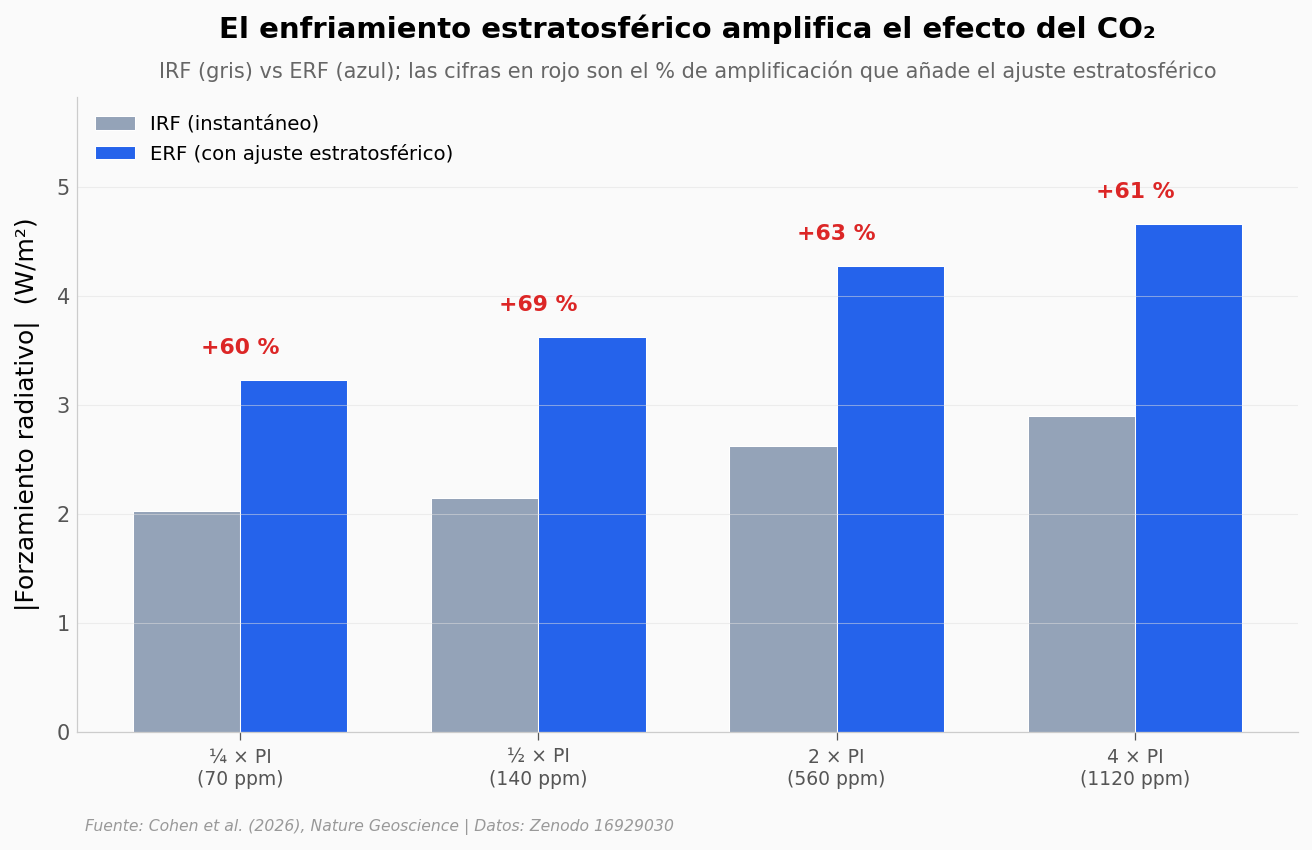

In [4]:
fig, ax = plt.subplots(figsize=(10.5, 5.5))

# Ordenar por factor_co2
df = erf_dbl.sort_values('factor_co2').reset_index(drop=True)

x = np.arange(len(df))
width = 0.36

# Barras IRF y ERF (valores absolutos para mejor visual — son negativos)
bars_irf = ax.bar(x - width/2, np.abs(df['irf_w_m2']), width,
                  label='IRF (instantáneo)', color='#94A3B8', edgecolor='white', linewidth=0.5)
bars_erf = ax.bar(x + width/2, np.abs(df['erf_w_m2']), width,
                  label='ERF (con ajuste estratosférico)', color=COLOR_PI, edgecolor='white', linewidth=0.5)

# Anotación % amplificación sobre cada par
for i, row in df.iterrows():
    pct = row['pct_amplificacion']
    h_max = max(abs(row['irf_w_m2']), abs(row['erf_w_m2']))
    ax.text(i, h_max + 0.2, f"+{pct:.0f} %",
            ha='center', va='bottom', fontsize=10.5,
            fontweight='bold', color=COLOR_2XPI)

# Etiquetas X — formato amigable
labels_x = []
for f in df['factor_co2']:
    if f == 0.25: labels_x.append('¼ × PI\n(70 ppm)')
    elif f == 0.5: labels_x.append('½ × PI\n(140 ppm)')
    elif f == 2.0: labels_x.append('2 × PI\n(560 ppm)')
    elif f == 4.0: labels_x.append('4 × PI\n(1120 ppm)')
    elif f == 8.0: labels_x.append('8 × PI\n(2240 ppm)')
    else: labels_x.append(f'{f} × PI')
ax.set_xticks(x)
ax.set_xticklabels(labels_x, fontsize=9)
ax.set_ylabel('|Forzamiento radiativo|  (W/m²)')
ax.set_ylim(0, np.abs(df['erf_w_m2']).max() * 1.25)
ax.set_title('El enfriamiento estratosférico amplifica el efecto del CO₂',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'IRF (gris) vs ERF (azul); las cifras en rojo son el % de amplificación que añade el ajuste estratosférico',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9.5, loc='upper left', framealpha=0.92)

fig.text(0.13, -0.01, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/erf_vs_irf_amplificacion.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan extremo es lo que están midiendo los reanálisis?

CMIP6 da una distribución de modelos. Los reanálisis son nuestra ventana a la atmósfera real. ¿Caen dentro del consenso de modelos, o muestran un enfriamiento más fuerte?

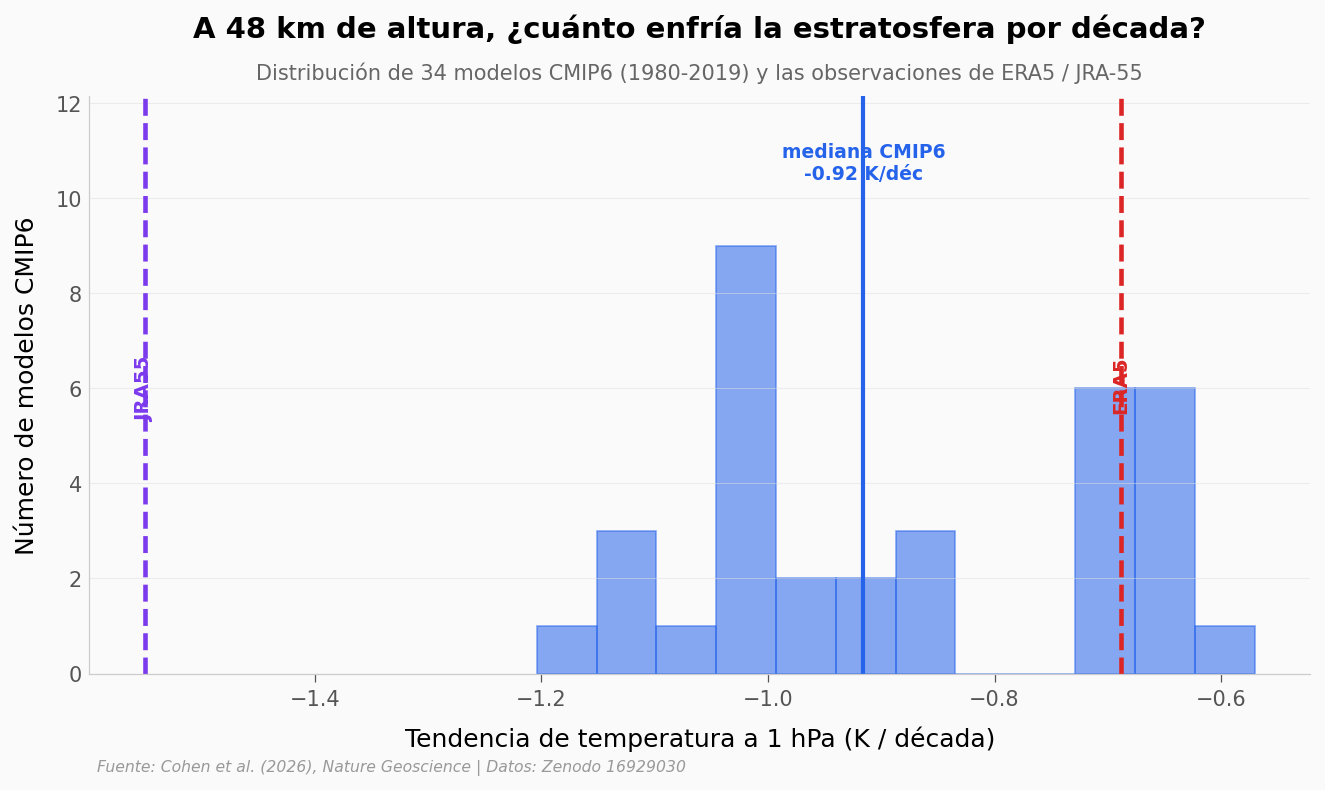


CMIP6 @ 1 hPa: 34 modelos
  mediana: -0.92 K/déc · IQR: [-1.03, -0.69]
  rango:   [-1.20, -0.57] K/déc
  ERA5: -0.69 K/déc
  JRA55: -1.55 K/déc


In [5]:
fig, ax = plt.subplots(figsize=(10.5, 5))

# Tendencias CMIP6 en la estratosfera alta (1 hPa)
cmip6_1hpa = cmip6[(cmip6['familia']=='CMIP6') & (np.isclose(cmip6['presion_hpa'], 1.0, atol=0.5))]
trends = cmip6_1hpa['tendencia_k_decada'].dropna().values

n, bins, patches = ax.hist(trends, bins=12, color=COLOR_PI, alpha=0.55,
                           edgecolor=COLOR_PI, linewidth=0.8)
y_max = n.max() * 1.35
ax.set_ylim(0, y_max)

# Mediana CMIP6
med = np.median(trends)
ax.axvline(x=med, color=COLOR_PI, linewidth=2.0, linestyle='-')
ax.text(med, y_max*0.92, f'mediana CMIP6\n{med:.2f} K/déc',
        color=COLOR_PI, fontsize=9, fontweight='bold',
        ha='center', va='top')

# Reanálisis @ 1 hPa
rea_1hpa = cmip6[(cmip6['modelo'].isin(['ERA5','JRA55'])) & (np.isclose(cmip6['presion_hpa'], 1.0, atol=0.5))]
colores_rea = {'ERA5': '#DC2626', 'JRA55': '#7C3AED'}
for _, row in rea_1hpa.iterrows():
    val = row['tendencia_k_decada']
    ax.axvline(x=val, color=colores_rea[row['modelo']], linewidth=2.2, linestyle='--')
    ax.text(val, y_max*0.55, row['modelo'], color=colores_rea[row['modelo']],
            fontsize=9.5, fontweight='bold', ha='center', va='top',
            rotation=90)

ax.set_xlabel('Tendencia de temperatura a 1 hPa (K / década)')
ax.set_ylabel('Número de modelos CMIP6')
ax.set_title('A 48 km de altura, ¿cuánto enfría la estratosfera por década?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Distribución de {len(trends)} modelos CMIP6 (1980-2019) y las observaciones de ERA5 / JRA-55',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_cooling_1hpa.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen numérico
print(f"\nCMIP6 @ 1 hPa: {len(trends)} modelos")
print(f"  mediana: {np.median(trends):.2f} K/déc · IQR: [{np.percentile(trends, 25):.2f}, {np.percentile(trends, 75):.2f}]")
print(f"  rango:   [{trends.min():.2f}, {trends.max():.2f}] K/déc")
if len(rea_1hpa) > 0:
    for _, row in rea_1hpa.iterrows():
        print(f"  {row['modelo']}: {row['tendencia_k_decada']:.2f} K/déc")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La estratosfera se enfría con más CO₂ | ✅ | Todos los escenarios Konrad y los 34 modelos CMIP6 que llegan a 1 hPa lo muestran. Mediana CMIP6 a 1 hPa = −0,92 K/déc; el modelo más cálido todavía enfría a −0,57 K/déc. Cero modelos con tendencia positiva en estratosfera alta. |
| Cada duplicación de CO₂ enfría 0-8 K la estratosfera | ⚠️ | El paper enmarca el resultado con un hedge (*roughly 0 to 8 K*). Nuestro cálculo de Konrad PI → 2 × CO₂ da rango 0 → 9,4 K (máx en estratopausa). El paper redondea al cuartil bajo del rango. |
| El enfriamiento amplifica el forzamiento del CO₂ ~50 % | ⚠️ | El paper dice "*about 50 %*". Nuestro cálculo directo (ERF − IRF) / IRF para 2 × PI da **+62,9 %** en el barrido de duplicaciones (SST = 287 K implícita). El barrido SST a 287 K da +69,2 % — los dos experimentos de Konrad usan setups numéricos distintos. La definición de "amplificación" también admite (ERF − IRF) / ERF, que daría +38,6 %. El paper no especifica cuál. Mantenemos las tres cifras visibles. |
| La tropopausa es invariante al CO₂ | ✅ | T a ≈ 98 hPa varía de 197,61 a 197,91 K entre 70 y 2240 ppm. Rango total: 0,30 K. |
| Reanálisis y CMIP6 coinciden cualitativamente | ✅ | A 1 hPa la mediana CMIP6 está en −0,92 K/déc; ERA5 mide −0,69 K/déc y JRA-55 mide −1,55 K/déc — ambos dentro del IQR de modelos. En la estratosfera alta los reanálisis muestran un enfriamiento más intenso (ERA5 llega a −1,84 K/déc a 3 hPa) que la mediana CMIP6, una discrepancia conocida que se discute desde hace dos décadas. |

> **Limitaciones:**
> - **Konrad es 1D idealizado:** sin dinámica meridional, sin H₂O variable, SST fija a 287 K. Captura la espectroscopia bien, pero no la circulación atmosférica.
> - **CMIP6 trends (1980-2019) mezclan señales:** además de CO₂, las tendencias estratosféricas incluyen el efecto de la recuperación del ozono y la variabilidad solar. El paper aísla la contribución del CO₂ vía perturbaciones controladas.
> - **Diferencia de 25 % relativo con el headline del paper sobre amplificación** está documentada arriba — no es un error, es una diferencia de definición que mantenemos visible.

## Ahora tú

Tres preguntas para explorar los datos:

1. **¿Cuánto enfría a 8 × CO₂ comparado con 2 × CO₂?** Pista: filtra `konrad` por `escenario` y compara `temperatura_k` al mismo nivel de presión. ¿Es el efecto lineal o se acelera?

2. **¿Cuál de los 36 modelos CMIP6 muestra el enfriamiento estratosférico más extremo?** Pista: agrupa `cmip6` por `modelo`, filtra niveles `<= 10 hPa`, y encuentra el mínimo de `tendencia_k_decada`.

3. **¿Cómo cambia la amplificación con la SST?** Pista: usa `erf_sst` y grafica `pct_amplificacion` vs `sst_k`. ¿Por qué un planeta más frío amplifica más?

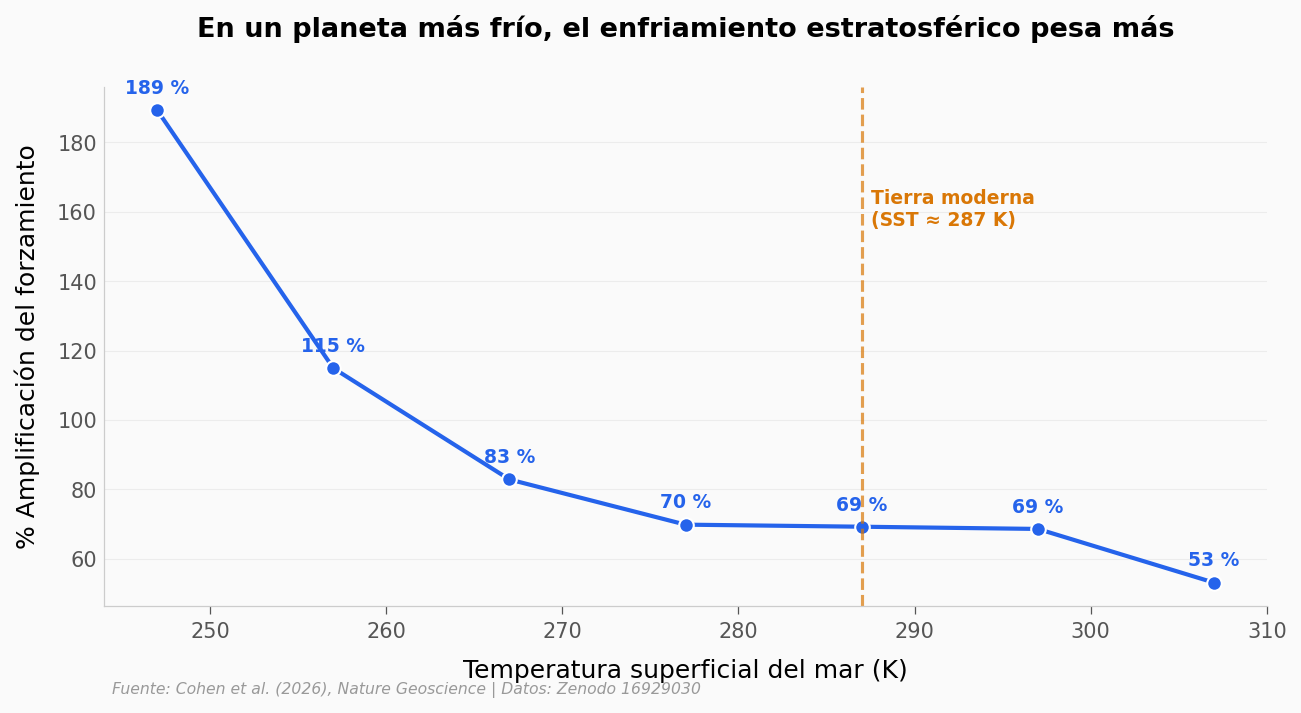


Observación: a SST muy bajas (247 K), el ajuste estratosférico ES casi todo el forzamiento (+189 %).
A SST cálidas (307 K) el ajuste vale ~50 % — la troposfera más caliente emite suficiente LW por su cuenta.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 3: ¿cómo cambia la amplificación con la SST?

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(erf_sst['sst_k'], erf_sst['pct_amplificacion'],
        color=COLOR_PI, linewidth=2.0, marker='o', markersize=7,
        markeredgecolor='white', markeredgewidth=1.0)

# Anotar valores en cada punto
for _, row in erf_sst.iterrows():
    ax.annotate(f"{row['pct_amplificacion']:.0f} %",
                xy=(row['sst_k'], row['pct_amplificacion']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=9, color=COLOR_PI, fontweight='bold')

# Marcar la SST "actual" (≈ 287 K — Tierra moderna)
ax.axvline(x=287, color=COLOR_REANALYSIS, linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(287.5, ax.get_ylim()[1]*0.85, 'Tierra moderna\n(SST ≈ 287 K)',
        color=COLOR_REANALYSIS, fontsize=9, fontweight='bold', va='top')

ax.set_xlabel('Temperatura superficial del mar (K)')
ax.set_ylabel('% Amplificación del forzamiento')
ax.set_title('En un planeta más frío, el enfriamiento estratosférico pesa más',
             fontsize=13, fontweight='bold', pad=24)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.show()

print("\nObservación: a SST muy bajas (247 K), el ajuste estratosférico ES casi todo el forzamiento (+189 %).")
print("A SST cálidas (307 K) el ajuste vale ~50 % — la troposfera más caliente emite suficiente LW por su cuenta.")

## Reproducir

Este notebook se ejecuta de extremo a extremo en menos de 30 segundos. Los archivos en `datos/` son extractos pre-procesados de los NetCDFs originales en Zenodo (5,1 GB de simulaciones Konrad + arrays de transferencia radiativa).

```bash
pip install pandas matplotlib numpy
jupyter execute notebook.ipynb
```

O abrir directamente en Colab: [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-13-co2-enfria-estratosfera/notebook.ipynb)

## Fuentes

**Paper**: [Stratospheric cooling and amplification of radiative forcing with rising carbon dioxide](https://doi.org/10.1038/s41561-026-01965-8)  
*Nature Geoscience, 2026-05-01*

**Dataset canónico**: [Raw data and plotting code for 'Why increases in CO2 cool the stratosphere and how this amplifies radiative forcing'](https://doi.org/10.5281/zenodo.16929030)  
*Zenodo, 2026-02-16 — NetCDFs Konrad + arrays IRF/ERF + tendencias CMIP6/reanálisis*

*12 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook generado para el canal Ciencia a Mordiscos — [cienciaamordiscos.com](https://cienciaamordiscos.com) · Repo: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Licencia datos: ver Zenodo origen · Licencia código: MIT*